In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Maps\\Bangalore\\Bangalore_Geo_Map_Data.csv')

In [6]:
df.drop(columns=['Unnamed: 0.1','Unnamed: 0'],inplace=True)

In [7]:
df

,location,quarter,year,min_price,max_price,avg_price,latitude,longitude,Risk
0,100 Feet Ring Road,Jan-Mar,2024,6658.540375,12574.33690,9770.560714,12.95570,77.601300,Moderate
1,100 Feet Ring Road,Apr-Jun,2024,6740.005214,12728.17938,9890.100000,12.95570,77.601300,Moderate
2,100 Feet Ring Road,Jul-Sep,2024,6756.918890,12760.12005,9914.918667,12.95570,77.601300,Moderate
3,100 Feet Ring Road,Oct-Dec,2024,6678.596142,12612.21126,9799.990000,12.95570,77.601300,Moderate
4,100 Feet Ring Road,Jan-Mar,2025,6570.093020,12407.30828,9640.775476,12.95570,77.601300,Moderate
...,...,...,...,...,...,...,...,...,...
4979,Yeswanthpur,Oct-Dec,2029,7232.798278,11488.14172,9360.470000,13.02383,77.552921,Moderate
4980,Yeswanthpur,Jan-Mar,2030,7681.570877,12200.94512,9941.258000,13.02383,77.552921,Moderate
4981,Yeswanthpur,Apr-Jun,2030,7721.040191,12263.63581,9992.338000,13.02383,77.552921,Moderate
4982,Yeswanthpur,Jul-Sep,2030,7726.376774,12272.11212,9999.244444,13.02383,77.552921,Moderate


In [8]:
import pandas as pd

df_filtered = df[df['year'] == 2024]

In [9]:
df_filtered.to_csv('Bangalore Predicted data for cagr.csv')

In [10]:
df1 = pd.read_csv('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Bangalore Predicted data for cagr.csv')

In [12]:
df1.drop(columns=['Unnamed: 0','latitude','longitude','Risk'],inplace=True)

In [13]:
df1

,location,quarter,year,min_price,max_price,avg_price
0,100 Feet Ring Road,Jan-Mar,2024,6658.540375,12574.336900,9770.560714
1,100 Feet Ring Road,Apr-Jun,2024,6740.005214,12728.179380,9890.100000
2,100 Feet Ring Road,Jul-Sep,2024,6756.918890,12760.120050,9914.918667
3,100 Feet Ring Road,Oct-Dec,2024,6678.596142,12612.211260,9799.990000
4,11th Main Road Malleshwaram,Jan-Mar,2024,6293.284708,10599.701140,8591.450000
...,...,...,...,...,...,...
707,Yelahanka New Town,Oct-Dec,2024,5389.820393,8012.298057,6700.990000
708,Yeswanthpur,Jan-Mar,2024,7681.570877,12200.945120,9941.258000
709,Yeswanthpur,Apr-Jun,2024,7721.040191,12263.635810,9992.338000
710,Yeswanthpur,Jul-Sep,2024,7726.376774,12272.112120,9999.244444


In [14]:
df2 = pd.read_csv('C:\\Users\\Administrator\\Downloads\\PropFTX AI2\\PropFTX AI2\\Bangalore_cagr_values.csv')

In [18]:
df2.drop(columns=['Unnamed: 0'],inplace=True)

In [19]:
df2

,Locality,Start_Price,End_Price,CAGR,CAGR (%)
0,100 feet ring road,9300.0,10139.0,0.014500,1.45
1,jakkuru layout,5300.0,9448.0,0.101144,10.11
2,rajajinagar,9219.0,18416.0,0.122239,12.22
3,thanisandra,5163.0,10459.0,0.124859,12.49
4,jalahalli,5601.0,7675.0,0.053907,5.39
...,...,...,...,...,...
234,hormavu agara,3200.0,5800.0,0.104196,10.42
235,jigani,4583.0,4685.0,0.003675,0.37
236,bannerughatta,5989.0,11318.0,0.111909,11.19
237,rachenahalli,3612.0,10587.0,0.196293,19.63


In [ ]:
import pandas as pd
import numpy as np


df1['location'] = df1['location'].str.lower()
df2['Locality'] = df2['Locality'].str.lower()

q4_2024 = df1[df1['quarter'] == 'Oct-Dec'][['location', 'avg_price']].rename(columns={'avg_price': 'initial_price'})

merged_df = q4_2024.merge(df2, left_on='location', right_on='Locality', how='inner')[['location', 'initial_price', 'CAGR']]

quarters = []
for year in range(2025, 2031):
    for q in ['Jan-Mar', 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']:
        quarters.append({'year': year, 'quarter': q})
quarters = pd.DataFrame(quarters)
quarters = quarters[quarters['year'] < 2031] 

def project_prices(initial_price, cagr, num_quarters):
    quarterly_cagr = (1 + cagr) ** (1/4) - 1
    prices = [initial_price]
    for _ in range(num_quarters):
        prices.append(prices[-1] * (1 + quarterly_cagr))
    return prices[1:]  

results = []
for _, row in merged_df.iterrows():
    location = row['location']
    initial_price = row['initial_price']
    cagr = row['CAGR']
    projected_prices = project_prices(initial_price, cagr, len(quarters))
    loc_df = pd.DataFrame({
        'location': location,
        'year': quarters['year'],
        'quarter': quarters['quarter'],
        'avg_price': projected_prices
    })
    results.append(loc_df)

final_df = pd.concat(results, ignore_index=True)

print(final_df)

final_df.to_csv('projected_prices_2025_2030.csv', index=False)

                location  year  quarter     avg_price
0     100 feet ring road  2025  Jan-Mar   9835.323288
1     100 feet ring road  2025  Apr-Jun   9870.783969
2     100 feet ring road  2025  Jul-Sep   9906.372501
3     100 feet ring road  2025  Oct-Dec   9942.089345
4     100 feet ring road  2026  Jan-Mar   9977.934964
...                  ...   ...      ...           ...
3619         yeswanthpur  2029  Oct-Dec  13999.577697
3620         yeswanthpur  2030  Jan-Mar  14268.058724
3621         yeswanthpur  2030  Apr-Jun  14541.688626
3622         yeswanthpur  2030  Jul-Sep  14820.566145
3623         yeswanthpur  2030  Oct-Dec  15104.791920

[3624 rows x 4 columns]


In [34]:
import pandas as pd

df1['location'] = df1['location'].str.lower().str.strip()
df2['Locality'] = df2['Locality'].str.lower().str.strip()

latest_prices = df1[df1['quarter'] == 'Oct-Dec']
latest_prices = latest_prices[['location', 'avg_price']].rename(columns={'avg_price': 'base_price'})

merged = pd.merge(latest_prices, df2, left_on='location', right_on='Locality')

years = list(range(2025, 2031))
quarters = ['Jan-Mar', 'Apr-Jun', 'Jul-Sep', 'Oct-Dec']
future_data = []

for _, row in merged.iterrows():
    locality = row['location']
    base_price = row['base_price']
    cagr = row['CAGR']

    current_price = base_price
    for year in years:
        current_price = current_price * (1 + cagr)
        for quarter in quarters:
            future_data.append({
                'location': locality,
                'year': year,
                'quarter': quarter,
                'predicted_price': round(current_price, 2)
            })

future_df = pd.DataFrame(future_data)

future_df = future_df.sort_values(by=['location', 'year', 'quarter'])

print(future_df.head())
future_df.to_csv('Bangalore_cagr_Data.csv')


             location  year  quarter  predicted_price
1  100 feet ring road  2025  Apr-Jun          9942.09
0  100 feet ring road  2025  Jan-Mar          9942.09
2  100 feet ring road  2025  Jul-Sep          9942.09
3  100 feet ring road  2025  Oct-Dec          9942.09
5  100 feet ring road  2026  Apr-Jun         10086.25


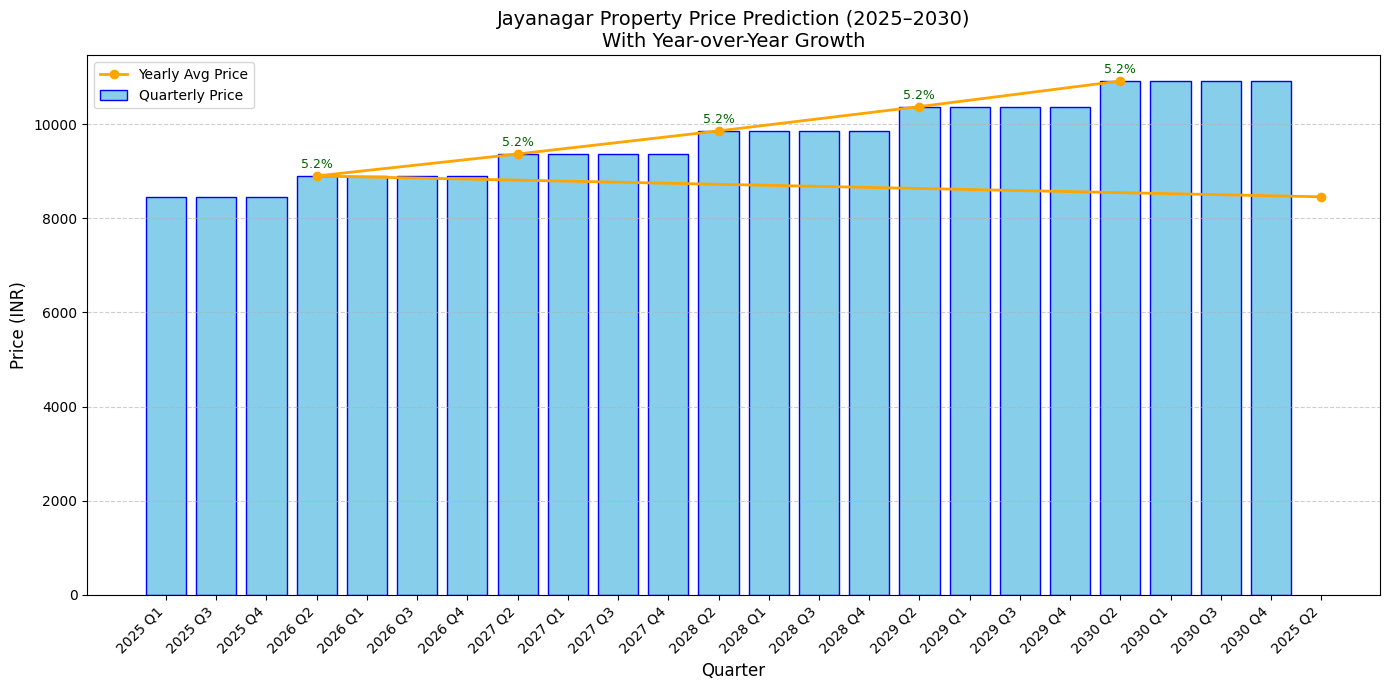

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data as a list of records
data = [
    [1752, "jayanagar", 2025, "Jan-Mar", 8455.8],
    [1754, "jayanagar", 2025, "Jul-Sep", 8455.8],
    [1755, "jayanagar", 2025, "Oct-Dec", 8455.8],
    [1756, "jayanagar", 2026, "Jan-Mar", 8898.75],
    [1757, "jayanagar", 2026, "Apr-Jun", 8898.75],
    [1758, "jayanagar", 2026, "Jul-Sep", 8898.75],
    [1759, "jayanagar", 2026, "Oct-Dec", 8898.75],
    [1760, "jayanagar", 2027, "Jan-Mar", 9364.89],
    [1761, "jayanagar", 2027, "Apr-Jun", 9364.89],
    [1762, "jayanagar", 2027, "Jul-Sep", 9364.89],
    [1763, "jayanagar", 2027, "Oct-Dec", 9364.89],
    [1764, "jayanagar", 2028, "Jan-Mar", 9855.45],
    [1765, "jayanagar", 2028, "Apr-Jun", 9855.45],
    [1766, "jayanagar", 2028, "Jul-Sep", 9855.45],
    [1767, "jayanagar", 2028, "Oct-Dec", 9855.45],
    [1768, "jayanagar", 2029, "Jan-Mar", 10371.71],
    [1769, "jayanagar", 2029, "Apr-Jun", 10371.71],
    [1770, "jayanagar", 2029, "Jul-Sep", 10371.71],
    [1771, "jayanagar", 2029, "Oct-Dec", 10371.71],
    [1772, "jayanagar", 2030, "Jan-Mar", 10915.01],
    [1773, "jayanagar", 2030, "Apr-Jun", 10915.01],
    [1774, "jayanagar", 2030, "Jul-Sep", 10915.01],
    [1775, "jayanagar", 2030, "Oct-Dec", 10915.01],
]

# Load into DataFrame
df = pd.DataFrame(data, columns=["id", "location", "year", "quarter", "price"])

# Create a quarter label for the x-axis
quarter_map = {"Jan-Mar": "Q1", "Apr-Jun": "Q2", "Jul-Sep": "Q3", "Oct-Dec": "Q4"}
df["quarter_label"] = df["quarter"].map(quarter_map)
df["label"] = df["year"].astype(str) + " " + df["quarter_label"]

# Sort data for plotting
df = df.sort_values(by=["year", "quarter"])

# Compute Yearly Average Prices
yearly_avg = df.groupby("year")["price"].mean().reset_index()
yearly_avg["YoY Growth (%)"] = yearly_avg["price"].pct_change() * 100

# Plot setup
plt.figure(figsize=(14, 7))

# Bar chart for each quarter
plt.bar(df["label"], df["price"], color='skyblue', edgecolor='blue', label='Quarterly Price')

growth_years = yearly_avg["year"].astype(str) + " Q2"     
plt.plot(growth_years, yearly_avg["price"], color='orange', marker='o', linewidth=2, label='Yearly Avg Price')
for i in range(1, len(yearly_avg)):
    x = growth_years.iloc[i]
    y = yearly_avg["price"].iloc[i]
    growth = yearly_avg["YoY Growth (%)"].iloc[i]
    plt.text(x, y + 100, f"{growth:.1f}%", ha='center', va='bottom', fontsize=9, color='darkgreen')

plt.title("Jayanagar Property Price Prediction (2025–2030)\nWith Year-over-Year Growth", fontsize=14)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Price (INR)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()
